## Introduction

In this project, I trained four models to detect stress signals in Reddit posts from multiple communities: TF-IDF+Logistic Regression (text-only), Logistic Regression (numeric features only), a hybrid TF-IDF+numeric model, and a fine-tuned DistilBERT model. Overall, DistilBERT achieved the best test-set performance (Test F1 ≈ 0.81), suggesting that contextual language modelling helps capture stress expressions beyond keyword matching.

## Import Libraries

Python version: 3.13.7

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score
import torch
import textwrap

## Reproducibility

Set random seed for reproducibility to ensure that results can be replicated.

In [42]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## Load Data

In [43]:
train_df = pd.read_csv("dreaddit-train.csv")

print(train_df.shape)
train_df.head(3)

(2838, 116)


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894


In [44]:
test_df  = pd.read_csv("dreaddit-test.csv")

print(test_df.shape)
test_df.head(3)

(715, 116)


,id,subreddit,post_id,sentence_range,text,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,896,relationships,7nu7as,"[50, 55]","Its like that, if you want or not.“ ME: I have...",0,0.8,1.514981e+09,22,-1.238793,...,1.0000,1.200,1.0,1.65864,1.32245,1.80264,0.63,62,-0.148707,0.000000
1,19059,anxiety,680i6d,"(5, 10)",I man the front desk and my title is HR Custom...,0,1.0,1.493348e+09,5,7.684583,...,1.4000,1.125,1.0,1.69133,1.69180,1.97249,1.00,2,7.398222,-0.065909
2,7977,ptsd,8eeu1t,"(5, 10)",We'd be saving so much money with this new hou...,1,1.0,1.524517e+09,10,2.360408,...,1.1429,1.000,1.0,1.70974,1.52985,1.86108,1.00,8,3.149288,-0.036818


## Data Preprocessing

Check for missing values and duplicates in the datasets.

In [45]:
print("Training Data:")
print(f"Number of rows with any missing value: {train_df.isna().any(axis=1).sum()}")
print(f"Number of duplicated rows: {train_df[train_df.duplicated()].shape[0]}")

print("\nTesting Data:")
print(f"Number of rows with any missing value: {test_df.isna().any(axis=1).sum()}")
print(f"Number of duplicated rows: {test_df[test_df.duplicated()].shape[0]}")

Training Data:
Number of rows with any missing value: 0
Number of duplicated rows: 0

Testing Data:
Number of rows with any missing value: 0
Number of duplicated rows: 0


For safety measure, fill missing values in the text column with empty strings and convert to string type.

In [46]:
train_df["text"] = train_df["text"].fillna("").astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

## Exploratory Data Analysis (EDA)

### Plot EDA1: Label Balance

Shows distribution of stressed vs non-stressed posts. The dataset is relatively balanced with slightly more stressed posts. Since the imbalance is not severe, there is no need for resampling. class_weight=balanced can be used during model training to account for any minor imbalance.

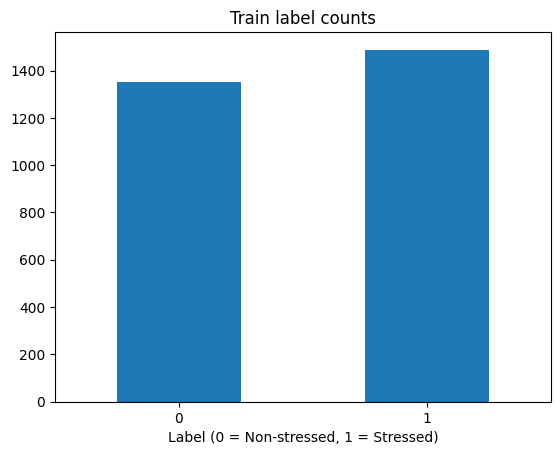

In [47]:
train_df["label"].value_counts().plot(kind="bar")
plt.title("Train label counts")
plt.xlabel("Label (0 = Non-stressed, 1 = Stressed)")
plt.xticks(rotation=0)
plt.gca().invert_xaxis()
plt.show()

### Plot EDA2: Subreddit Distribution

Shows number of posts from each subreddit. The dataset spans multiple Reddit communities, but the representation is uneven. Subreddits such as ptsd, relationships, and anxiety contribute substantially more samples than others like food_pantry or almosthomeless. This imbalance in subreddit representation may influence model performance, potentially biasing predictions towards the more represented communities.

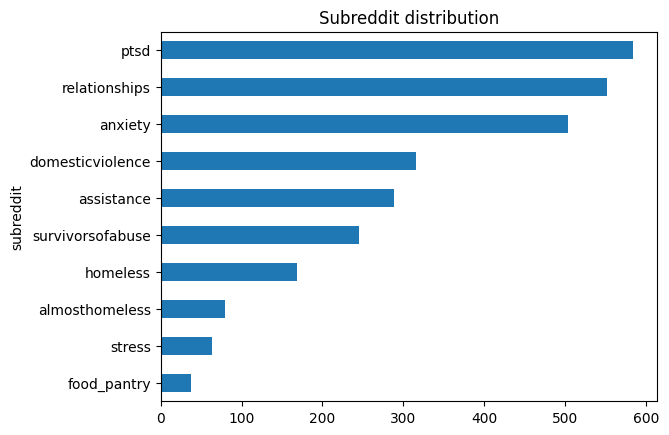

In [48]:
train_df["subreddit"].value_counts().plot(kind="barh")
plt.title("Subreddit distribution")
plt.gca().invert_yaxis()
plt.show()

### Plot EDA3: Stress Rate by Subreddit

Shows proportion of posts labeled as stressed within each subreddit. Subreddits like anxiety and domesticviolence have higher stress rates (>50%), while others like food_pantry and homeless have lower stress rates (<40%). This suggests that the subreddit itself contains predictive information.

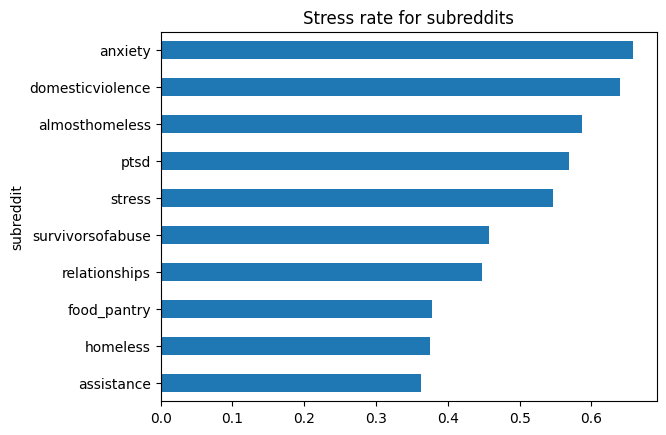

In [49]:
tmp_df = train_df.groupby("subreddit")["label"].agg(["count","mean"]).sort_values("mean", ascending=False)
tmp_df["mean"].plot(kind="barh")
plt.title("Stress rate for subreddits")
plt.gca().invert_yaxis()
plt.show()

### Plot EDA4: Word Count by Stress Label

Shows distribution of word counts for stressed vs non-stressed posts. Stressed posts are slightly longer on average, but there is significant overlap in both distributions, suggesting that word count alone is not a strong predictor of stress.

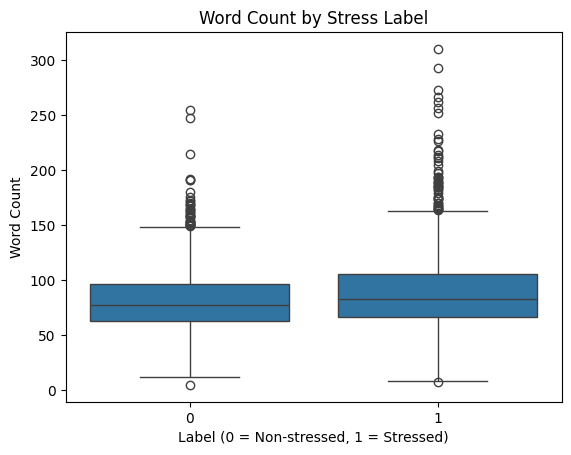

In [50]:
sns.boxplot(x="label", y="lex_liwc_WC", data=train_df)
plt.title("Word Count by Stress Label")
plt.xlabel("Label (0 = Non-stressed, 1 = Stressed)")
plt.ylabel("Word Count")
plt.show()

### Plot EDA5: Log(Number of Comments) by Stress Label

Shows distribution of comment counts by label. Both distributions are extremely similar, indicating that the number of comments is not a strong predictor of stress.

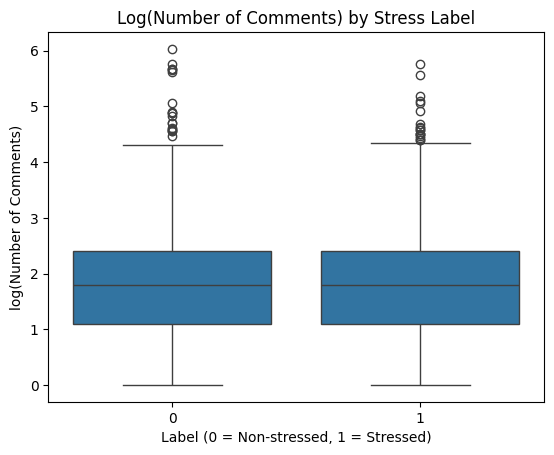

In [51]:
sns.boxplot(x=train_df["label"], y=np.log1p(train_df["social_num_comments"]))
plt.title("Log(Number of Comments) by Stress Label")
plt.xlabel("Label (0 = Non-stressed, 1 = Stressed)")
plt.ylabel("log(Number of Comments)")
plt.show()

### Plot EDA6: Correlation Between Selected LIWC Features

Shows pairwise correlations between selected psychological LIWC features. Strong correlations exist between negemo, affect, and anx, suggesting emotional dimensions cluster together. Some features show negative correlations. Since many engineered features are not independent, there is a need to handle multicollinearity.

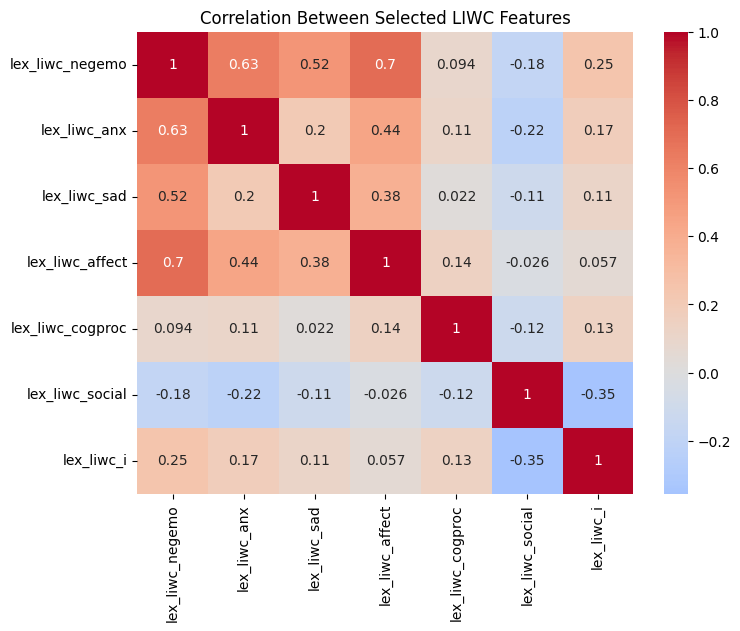

In [52]:
selected_liwc = [
    "lex_liwc_negemo",
    "lex_liwc_anx",
    "lex_liwc_sad",
    "lex_liwc_affect",
    "lex_liwc_cogproc",
    "lex_liwc_social",
    "lex_liwc_i"
]
corr_df = train_df[selected_liwc].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Selected LIWC Features")
plt.show()

### Plot EDA7: LIWC Negative Emotion Score by Stress Label

Shows distribution of negative emotion scores across stressed vs non-stressed posts. Stressed posts have higher negative emotion scores, suggesting that they contain more negative emotional language.

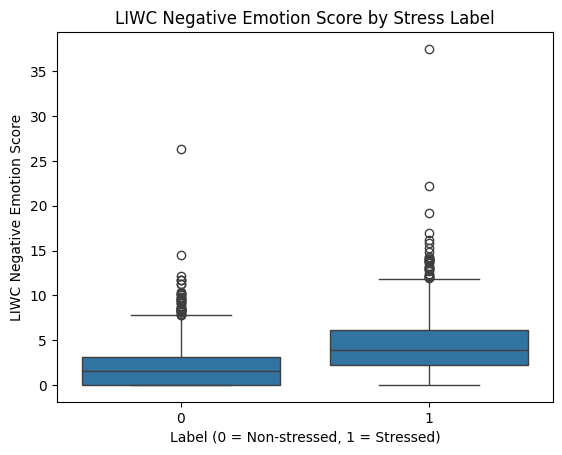

In [53]:
sns.boxplot(x="label", y="lex_liwc_negemo", data=train_df)
plt.title("LIWC Negative Emotion Score by Stress Label")
plt.xlabel("Label (0 = Non-stressed, 1 = Stressed)")
plt.ylabel("LIWC Negative Emotion Score")
plt.show()

## Define features

In [54]:
TEXT_COL = "text"
GROUP_COL = "subreddit"
TARGET_COL = "label"

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in [TARGET_COL, "id", "post_id"]]

print(f"Number of numeric features: {len(numeric_cols)}")
print(numeric_cols[:10])

Number of numeric features: 110
['confidence', 'social_timestamp', 'social_karma', 'syntax_ari', 'lex_liwc_WC', 'lex_liwc_Analytic', 'lex_liwc_Clout', 'lex_liwc_Authentic', 'lex_liwc_Tone', 'lex_liwc_WPS']


## Model 1: TF-IDF + Logistic Regression (Text-Only)

TF-IDF stands for Term Frequency-Inverse Document Frequency, which is a numerical statistic that reflects how important a word is to a document in a collection. It is good for short social media texts because it captures discriminative keywords/phrases efficiently. Logistic Regression, other than being simple and fast to train, is chosen for its interpretability since we can inspect its coefficients to understand which features contribute most to stress prediction.

In [55]:
def make_text_only_model():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=2,
            max_features=200_000
        )),
        ("clf", LogisticRegression(
            solver="saga",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

text_model = make_text_only_model()

## Model 2: Logistic Regression (Numeric Features Only)

This model uses only the engineered numeric features like LIWC scores, word count, and comment count to predict stress. I wanted to test how much predictive signal is already present in the engineered features and metadata features without directly modeling the text. Logistic Regression, other than being simple and fast to train, is chosen for its interpretability since we can inspect its coefficients to understand which features contribute most to stress prediction.

In [56]:
def make_numeric_only_model():
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", MaxAbsScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

numeric_model = make_numeric_only_model()

## Model 3: TF-IDF + Numeric + Logistic Regression(Text + Numeric Hybrid)

I wanted to see if a combination of TF-IDF and numeric features would improve performance over either alone, by capturing both lexical patterns, metadata features, and high-level semantic signals like negative emotion. Logistic Regression, other than being simple and fast to train, is chosen for its interpretability since we can inspect its coefficients to understand which features contribute most to stress prediction.

In [57]:
def make_hybrid_model(numeric_cols):
    preprocess = ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1,2),
                min_df=2,
                max_features=200_000
            ), TEXT_COL),
            ("num", Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", MaxAbsScaler()),
            ]), numeric_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    return Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            solver="saga",
            class_weight="balanced",
            max_iter=4000,
            random_state=RANDOM_STATE
        ))
    ])

hybrid_model  = make_hybrid_model(numeric_cols)

## Model 4: BERT (Text-Only)

To capture contextual and compositional meaning beyond bag-of-words, I fine-tuned a pretrained transformer model "distilbert-base-uncased" for binary sequence classification. Posts are tokenized with truncation/padding (max length 256). The model is trained on a stratified train/validation split, selecting the best checkpoint based on validation F1. This model is less directly interpretable than Logistic Regression, but it can better handle context, phrasing, and indirect expressions of stress. It is also smaller and faster to train compared to BERT, while sacrificing minimal performance.

In [59]:
device = "cpu"

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_df["label"]
)

print(train_split.shape, val_split.shape)

BERT_MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = Dataset.from_pandas(train_split[["text", "label"]]).map(tokenize_batch, batched=True)
val_ds   = Dataset.from_pandas(val_split[["text", "label"]]).map(tokenize_batch, batched=True)
test_ds  = Dataset.from_pandas(test_df[["text", "label"]]).map(tokenize_batch, batched=True)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    if "__index_level_0__" in ds.column_names:
        ds = ds.remove_columns(["__index_level_0__"])
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    if name == "train":
        train_ds = ds
    elif name == "val":
        val_ds = ds
    else:
        test_ds = ds

print(train_ds[0].keys())

bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {"precision": p, "recall": r, "f1": f1}

bert_training_args = TrainingArguments(
    output_dir="bert_out",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    weight_decay=0.01,
    logging_steps=50,
    seed=RANDOM_STATE,

    report_to="none"
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

(2270, 116) (568, 116)


Map: 100%|██████████| 715/715 [00:00<00:00, 11322.35 examples/s]


dict_keys(['label', 'input_ids', 'attention_mask'])


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1280.09it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Evaluation: k-Fold Cross Validation

Done on the three models above to evaluate their performance and stability across different subsets of the data. Since the standard deviations of the F1 scores are relatively low, it suggests that the models are performing consistently across different folds. The mean F1 scores are high, indicating good predictive performance.

In [78]:
def cv_f1(model, X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=skf, scoring="f1")
    return scores.mean(), scores.std()

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL].astype(int)

X_test  = test_df.drop(columns=[TARGET_COL], errors="ignore")
y_test  = test_df[TARGET_COL].astype(int) if TARGET_COL in test_df.columns else None

m1, s1 = cv_f1(text_model, train_df[TEXT_COL], y_train)
m2, s2 = cv_f1(numeric_model, train_df[numeric_cols], y_train)
m3, s3 = cv_f1(hybrid_model, train_df[[TEXT_COL] + numeric_cols], y_train)

cv_results_df = pd.DataFrame({
    "Model": ["TF-IDF", "Numeric", "Hybrid"],
    "CV F1 (mean)": [m1, m2, m3],
    "CV F1 (std)":  [s1, s2, s3],
})
cv_results_df

,Model,CV F1 (mean),CV F1 (std)
0,TF-IDF,0.750481,0.015543
1,Numeric,0.769374,0.015124
2,Hybrid,0.778345,0.017935


## Evaluation: F1 Scores on Test Set

BERT outperforms the other models, achieving the highest F1 score on the test set. The hybrid model performs better than the text-only and numeric-only models, indicating that combining text and numeric features provides a performance boost.

In [60]:
text_model.fit(train_df[TEXT_COL], y_train)
text_test_pred = text_model.predict(test_df[TEXT_COL])
text_test_f1 = f1_score(y_test, text_test_pred)

numeric_model.fit(train_df[numeric_cols], y_train)
numeric_test_pred = numeric_model.predict(test_df[numeric_cols])
numeric_test_f1 = f1_score(y_test, numeric_test_pred)

hybrid_model.fit(train_df[[TEXT_COL] + numeric_cols], y_train)
hybrid_test_pred = hybrid_model.predict(test_df[[TEXT_COL] + numeric_cols])
hybrid_test_f1 = f1_score(y_test, hybrid_test_pred)

bert_trainer.train()
bert_test_out = bert_trainer.predict(test_ds)
bert_test_pred = np.argmax(bert_test_out.predictions, axis=1)
bert_test_f1 = f1_score(y_test, bert_test_pred)

print(f"Text-only Test F1: {text_test_f1}")
print(f"Numeric-only Test F1: {numeric_test_f1}")
print(f"Hybrid Test F1: {hybrid_test_f1}")
print(f"BERT Test F1: {bert_test_f1}")

C:\Users\leeya\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.430362,0.429192,0.865079,0.731544,0.792727
2,0.276693,0.525676,0.821306,0.802013,0.811545
3,0.225599,0.691922,0.810458,0.832215,0.821192


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.62it/s]
C:\Users\leeya\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.55it/s]
C:\Users\leeya\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.71it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
C:\Users\leeya\AppData\R

Text-only Test F1: 0.7282184655396619
Numeric-only Test F1: 0.768
Hybrid Test F1: 0.7724867724867724
BERT Test F1: 0.8123393316195373


## Evaluation: Overall Results

BERT performs the best with a test F1 score of 0.81 (2 d.p.). It likely captures more complex language patterns and contextual information compared to the other models, which rely on simpler representations.

In [61]:
overall_results_df = pd.DataFrame({
    "Model": ["TF-IDF", "Numeric", "Hybrid", "BERT"],
    "CV F1 (mean)": [m1, m2, m3, np.nan],
    "CV F1 (std)":  [s1, s2, s3, np.nan],
    "Val F1": [np.nan, np.nan, np.nan, bert_trainer.state.best_metric],
    "Test F1": [text_test_f1, numeric_test_f1, hybrid_test_f1, f1_score(test_df["label"].astype(int), bert_test_pred)]
})
overall_results_df

,Model,CV F1 (mean),CV F1 (std),Val F1,Test F1
0,TF-IDF,0.750481,0.015543,NaN,0.728218
1,Numeric,0.769374,0.015124,NaN,0.768000
2,Hybrid,0.778345,0.017935,NaN,0.772487
3,BERT,NaN,NaN,0.821192,0.812339


## Analysis 1: Which subreddit is easier to predict and why

To find out which subreddit is easier to predict, we can compute the F1 score for each subreddit separately. This will allow us to see if there are certain subreddits where the model performs particularly well or poorly.

In [62]:
def f1_per_group(df, y_true, y_pred, group_col="subreddit"):
    out = []
    y_pred = np.asarray(y_pred)
    for g, idx in df.groupby(group_col).groups.items():
        yt = y_true.iloc[idx]
        yp = y_pred[idx]
        if yt.nunique() < 2:
            continue
        out.append((g, len(idx), f1_score(yt, yp)))

    return pd.DataFrame(out, columns=["subreddit", "n", "f1"]).sort_values("f1", ascending=False)

per_sub_text_df   = f1_per_group(test_df, y_test, text_test_pred, group_col=GROUP_COL)
per_sub_num_df    = f1_per_group(test_df, y_test, numeric_test_pred, group_col=GROUP_COL)
per_sub_hybrid_df = f1_per_group(test_df, y_test, hybrid_test_pred, group_col=GROUP_COL)
per_sub_bert_df   = f1_per_group(test_df, y_test, bert_test_pred, group_col=GROUP_COL)

Subreddits like "anxiety", "ptsd", "stress", and "domesticviolence" have higher F1 scores across all 4 models, indicating that the model is better at predicting stress in these communities. These subreddits may contain more explicit discussions about stress and related issues, thus making it easier for the model to learn relevant patterns.

The sample size for the 4 subreddits mentioned above are also relatively large, except for "stress" which has only 14 samples. This means that the F1 scores for "anxiety", "ptsd", and "domesticviolence" are more reliable, while the F1 score for "stress" may be less reliable due to the small sample size.

The "relationships" subreddit has a moderate F1 score, which may be due to the fact that while it contains discussions about stress, it also includes a lot of content that is not directly related to stress, making it harder for the model to learn clear patterns.

In [63]:
t = per_sub_text_df[["subreddit", "f1"]].rename(columns={"f1": "TF-IDF"})
n = per_sub_num_df[["subreddit", "f1"]].rename(columns={"f1": "Numeric"})
h = per_sub_hybrid_df[["subreddit", "f1"]].rename(columns={"f1": "Hybrid"})
b = per_sub_bert_df[["subreddit", "f1"]].rename(columns={"f1": "BERT"})

subreddit_compare_df = (
    t.merge(n, on="subreddit", how="outer")
     .merge(h, on="subreddit", how="outer")
     .merge(b, on="subreddit", how="outer")
)

sub_counts_df = (
    test_df["subreddit"]
    .value_counts()
    .rename_axis("subreddit")
    .reset_index(name="n")
)

subreddit_compare_df = subreddit_compare_df.merge(sub_counts_df, on="subreddit", how="left")
subreddit_compare_df = subreddit_compare_df.sort_values("n", ascending=False)
subreddit_compare_df

,subreddit,TF-IDF,Numeric,Hybrid,BERT,n
1,anxiety,0.802139,0.837696,0.835979,0.863388,147
7,relationships,0.594203,0.637168,0.596491,0.692913,142
6,ptsd,0.814815,0.804878,0.826347,0.845238,127
3,domesticviolence,0.747253,0.831461,0.860215,0.842105,72
9,survivorsofabuse,0.603175,0.696970,0.696970,0.750000,70
2,assistance,0.717949,0.750000,0.789474,0.871795,66
5,homeless,0.666667,0.615385,0.634146,0.727273,52
0,almosthomeless,0.608696,0.695652,0.695652,0.869565,19
8,stress,0.842105,0.900000,0.900000,0.900000,14
4,food_pantry,0.800000,0.800000,0.800000,0.857143,6


## Analysis 2: High-confidence wrong predictions

Since BERT uses probabilities to make predictions, we can look at the cases where BERT was very confident in its wrong predictions. This can help us understand where the model is making mistakes and why.

In [64]:
bert_probs = torch.softmax(torch.tensor(bert_test_out.predictions), dim=1).numpy()
p_stress = bert_probs[:, 1]

err_bert_df = test_df.copy()
err_bert_df["y_true"] = y_test.values
err_bert_df["y_pred"] = bert_test_pred
err_bert_df["p_stress"] = p_stress
err_bert_df["wrong"] = (err_bert_df["y_true"] != err_bert_df["y_pred"])
err_bert_df["confidence"] = np.max(bert_probs, axis=1)

pd.reset_option("display.max_colwidth")
err_bert_df.head(2)

,id,subreddit,post_id,sentence_range,text,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment,y_true,y_pred,p_stress,wrong
0,896,relationships,7nu7as,"[50, 55]","Its like that, if you want or not.“ ME: I have...",0,0.993862,1.514981e+09,22,-1.238793,...,1.32245,1.80264,0.63,62,-0.148707,0.000000,0,0,0.006138,False
1,19059,anxiety,680i6d,"(5, 10)",I man the front desk and my title is HR Custom...,0,0.987582,1.493348e+09,5,7.684583,...,1.69180,1.97249,1.00,2,7.398222,-0.065909,0,0,0.012418,False


To be specific, we choose posts from the "anxiety" (F1=0.863388), "relationships" (F1=0.692913), and "ptsd" (F1=0.845238) subreddits. They have the largest sample size and represent a range of F1 scores, which allows us to analyze both high-performing and moderate-performing subreddits. Then, we choose one false positive and one false negative from each subreddit, and look at the text of the posts to understand why the model made those mistakes.

In [65]:
SUBREDDITS = ["anxiety", "relationships", "ptsd"]
TOP_K = 1

cases = []

for sub in SUBREDDITS:
    sub_df = err_bert_df[err_bert_df["subreddit"] == sub]
    fp = (sub_df[(sub_df["y_true"] == 0) & (sub_df["y_pred"] == 1)]
          .sort_values("p_stress", ascending=False)
          .head(TOP_K))
    fn = (sub_df[(sub_df["y_true"] == 1) & (sub_df["y_pred"] == 0)]
          .sort_values("p_stress", ascending=True)
          .head(TOP_K))
    if len(fp) > 0:
        cases.append(fp.assign(error_type="FP"))
    if len(fn) > 0:
        cases.append(fn.assign(error_type="FN"))

selected_cases_df = pd.concat(cases, axis=0)

selected_cases_cols = ["subreddit", "error_type", "y_true", "y_pred", "p_stress", "confidence"]
if "id" in selected_cases_df.columns:
    selected_cases_cols = ["id"] + selected_cases_cols

selected_cases_df[selected_cases_cols]

,id,subreddit,error_type,y_true,y_pred,p_stress,confidence
480,317,anxiety,FP,0,1,0.992994,0.992994
493,26210,anxiety,FN,1,0,0.010839,0.989161
242,1976,relationships,FP,0,1,0.994403,0.994403
174,1569,relationships,FN,1,0,0.004519,0.995481
401,160,ptsd,FP,0,1,0.994464,0.994464
566,6333,ptsd,FN,1,0,0.005017,0.994983


### Case 1: "anxiety", False Positive

The text contains distress cues like "overwhelmed and anxious", "I feel like I am lost", and "won't be able to cope", which likely led the model to predict stressed. However, the post is labelled as non-stressed, likely because the author "began talking to [people]" and "feel better".

In [66]:
print(textwrap.fill(test_df.loc[test_df["id"]==317, "text"].iloc[0], width=100))

I don't remember always being like this, but over the last two years or so I have had a few
tumultuous friendships/dating connections with people (I make deep connections quickly, or seemingly
deep anyways with lots of self disclosure and vice versa) and after things don't work out I feel
like I am lost and won't be able to cope on my own. I recently started talking to someone again
after not talking to them for a few months, there was no bad blood between us we just decided it
would be best to move on and not talk anymore. They reached out first about a month ago, then
nothing. I have been going through it at work, feeling overwhelmed and anxious and so I feel stupid
for doing this but I began talking to them again. I feel better, even if its slight.


### Case 2: "anxiety", False Negative

The framing of the post is more about seeking solutions and understanding, rather than expressing distress, which may have led the model to predict non-stressed. However, the underlying content is that the author is probably more prone to anxiety, which is why it was labeled as actually stressed.

In [67]:
print(textwrap.fill(test_df.loc[test_df["id"]==26210, "text"].iloc[0], width=100))

I've read that quality sleep, regular exercise, and fish oil all can help. Does that sound right?
What are the best, non-pharma methods to help resolve anxiety? What about mediation (and is there a
suggested starting point)? While I'm probably genetically more prone to anxiety, is it that I've let
my body down somehow?


### Case 3: "relationships", False Positive

BERT likely misclassified this post due to keywords like "pretend to like", "hating myself", "leading him on", which resemble distress signals. The actual label may be 0 because it’s more about values or commitment conflict than a direct stress episode.

In [68]:
print(textwrap.fill(test_df.loc[test_df["id"]==1976, "text"].iloc[0], width=100))

I can't guarantee that I will never change my mind, but I've never dreamt of happily ever after, I
don't really believe in eternal love and soulmates and all this stuff so I guess it's not really
likely. I'm not asexual or aromantic, I love sex and I love him in a non-platonic way, I just can't
compromise on that kind of thing, I wouldn't even know how to do it. I could meet his family,
pretend to like them, pretend to bond with them and pretend to care, but that's really just lying to
make him happy. I've tried it before and it makes me hating myself and them. I've always told him
the the truth about the level of commitment I'm comfortable with, but nevertheless I feel like I'm
leading him on.


### Case 4: "relationships", False Negative

The post describes major stressors like financial strain, newborn sleep deprivation, and increased conflict, but in a narrative style. BERT may miss stress when it’s expressed as such without explicit anxiety or negative-emotion wording.

In [69]:
print(textwrap.fill(test_df.loc[test_df["id"]==1569, "text"].iloc[0], width=100))

He is our little angel and we are both gaga for him, but money has been extraordinary tight,
adjusting to parent life and sleep deprivation has been tough for both of us. We were fighting and
bickering a bit for the first time in his first months of life, but I figured that was normal for
new parents. I work in the financial industry for a modest income (working hard currently to get to
the next level where I'll make substantially more) and she works for an arts-based nonprofit. I have
no particular attachment to the financial industry, it's just been a way to pay the bills and I find
it interesting enough. She's a passionate artist though, always knew she wanted to be one, and it's
really important to her.


### Case 5: "ptsd", False Positive

Trauma-trigger language and mistrust like "triggers", and seeing boyfriend as abusive ex, makes the model strongly predict stress. The actual label may be non-stressed because the author may be describing past trauma without currently experiencing stress, or they may have developed coping mechanisms that mitigate their stress levels.

In [70]:
print(textwrap.fill(test_df.loc[test_df["id"]==160, "text"].iloc[0], width=100))

Now I’m in a healthy relationship. This man is the love of my life. He always pushes for me to be
better and I resist it sometimes. I’ve turned on him fearing him having a dark objective, and I
don’t understand all my triggers. All I know is sometimes I see my incredibly loving boyfriend as my
incredibly abusive ex and it breaks my heart because he’s the only person that tends to me so
well... he does everything he can to help me always he saved me from that awful relationship... he
saved my life.


### Case 6: "ptsd", False Negative

The writer explicitly discusses traumatic "episodes" becoming "too intense" and asks for support, which aligns with stress. BERT likely misclassified it because the phrasing is reflective and coping-focused, with fewer obvious negative-emotion keywords.

In [71]:
print(textwrap.fill(test_df.loc[test_df["id"]==6333, "text"].iloc[0], width=100))

I would like to reach out for help from someone supportive before an episode becomes too intense to
ask for help. I would like to acknowledge the symptoms and temporary nature of the situation as to
let it pass without causing additional damage. I finally realized that fighting my traumatic
episodes is like a rigid oak tree trying to resist a flooding dam. Do any of you guys have ways to
be "okay" with an episode? If so, how do you find the flexibility and patience to not fight against
it?


## Analysis 3: Specific features or phrases that predict stress

Since BERT is a black-box model, we cannot easily interpret which specific features or phrases it uses to make predictions. However, for the Logistic Regression models, we can look at the coefficients to identify which features or phrases are most predictive of stress.

### 3A: Top phrases that predict stress in TF-IDF + Logistic Regression model

The TF-IDF + Logistic Regression model outputs a coefficient for each phrase in the vocabulary, which indicates how strongly that phrase is associated with the stressed label. By looking at the top positive coefficients, we can identify which phrases are most predictive of stress.

In [72]:
tfidf = text_model.named_steps["tfidf"]
clf   = text_model.named_steps["clf"]

feature_names = tfidf.get_feature_names_out()
coefs = clf.coef_.ravel()

TOPN = 25
top_pos_idx = np.argsort(coefs)[-TOPN:][::-1]
top_neg_idx = np.argsort(coefs)[:TOPN]

top_phrases_stress_df = pd.DataFrame({
    "phrase": feature_names[top_pos_idx],
    "coef": coefs[top_pos_idx]
})

top_phrases_notstress_df = pd.DataFrame({
    "phrase": feature_names[top_neg_idx],
    "coef": coefs[top_neg_idx]
})

top_phrases_stress_df.head(10), top_phrases_notstress_df.head(10)

(     phrase      coef
 0      feel  2.968749
 1      just  2.767331
 2       don  2.472172
 3   anxiety  2.325564
 4  don know  2.277630
 5    scared  1.884385
 6   fucking  1.736238
 7      hate  1.689699
 8      need  1.566300
 9      tell  1.512722,
      phrase      coef
 0       url -2.192068
 1       met -1.881334
 2     thank -1.588187
 3    survey -1.396848
 4     years -1.323732
 5     share -1.185497
 6      free -1.180429
 7     great -1.074379
 8    person -1.047206
 9  let know -1.028592)

### 3A Plot: Top TF-IDF phrases predicting stress (text-only model)

The strongest “stress” predictors are mostly high-frequency, emotionally loaded words like anxiety/anxious, scared, afraid, hate, don’t know and intensifiers/profanity, suggesting the text-only model mainly keys on negative affect and uncertainty rather than specific topics.

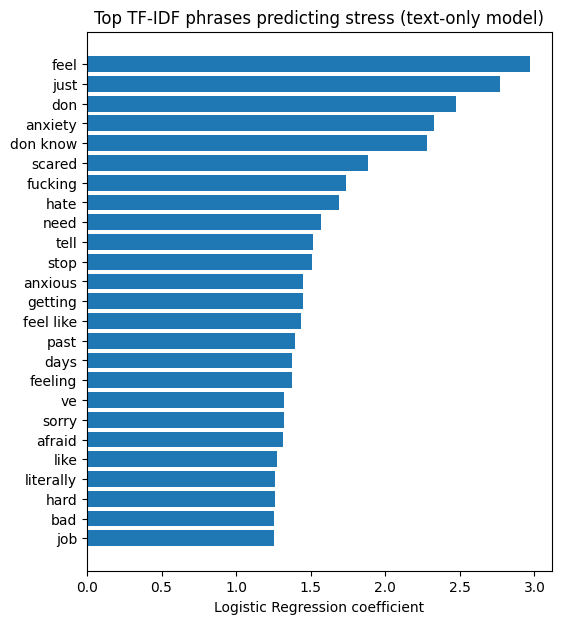

In [73]:
plt.figure(figsize=(6,7))
plt.barh(top_phrases_stress_df["phrase"][::-1], top_phrases_stress_df["coef"][::-1])
plt.title("Top TF-IDF phrases predicting stress (text-only model)")
plt.xlabel("Logistic Regression coefficient")
plt.show()

### 3B: Top numeric features that predict stress in Numeric-Only Logistic Regression model

The Numeric-Only Logistic Regression model outputs a coefficient for each numeric feature, which indicates how strongly that feature is associated with the stressed label. By looking at the top positive coefficients, we can identify which numeric features are most predictive of stress.

In [74]:
clf_num = numeric_model.named_steps["clf"]
coefs_num = clf_num.coef_.ravel()

TOPN = 25
top_pos_idx = np.argsort(coefs_num)[-TOPN:][::-1]
top_neg_idx = np.argsort(coefs_num)[:TOPN]

top_num_stress_df = pd.DataFrame({
    "feature": np.array(numeric_cols)[top_pos_idx],
    "coef": coefs_num[top_pos_idx]
})

top_num_notstress_df = pd.DataFrame({
    "feature": np.array(numeric_cols)[top_neg_idx],
    "coef": coefs_num[top_neg_idx]
})

top_num_stress_df.head(10), top_num_notstress_df.head(10)

(                 feature      coef
 0            lex_liwc_WC  1.845370
 1          lex_liwc_feel  1.845336
 2         lex_liwc_death  1.814139
 3      lex_liwc_function  1.733235
 4          lex_liwc_risk  1.516108
 5  lex_liwc_focuspresent  1.507125
 6           lex_liwc_Dic  1.487132
 7        lex_liwc_affect  1.274890
 8             lex_liwc_i  1.230653
 9          lex_liwc_home  1.162029,
                     feature      coef
 0  lex_dal_min_pleasantness -2.202755
 1           lex_liwc_differ -1.664634
 2            lex_liwc_Comma -1.661329
 3            lex_liwc_Clout -1.579195
 4                 sentiment -1.408266
 5           lex_liwc_ingest -1.367518
 6             lex_liwc_Tone -1.293074
 7  lex_dal_avg_pleasantness -1.210934
 8              social_karma -1.087392
 9              lex_liwc_see -1.041440)

### 3B Plot: Top numeric features predicting stress (numeric-only model)

The top engineered predictors are largely LIWC emotion + self-focus + intensity markers like feel, anx, negemo, anger, swear, QMark, i and length/verbosity from lex_liwc_WC, WPS, indicating stressed posts tend to be more affective, more first-person, and more expressive.

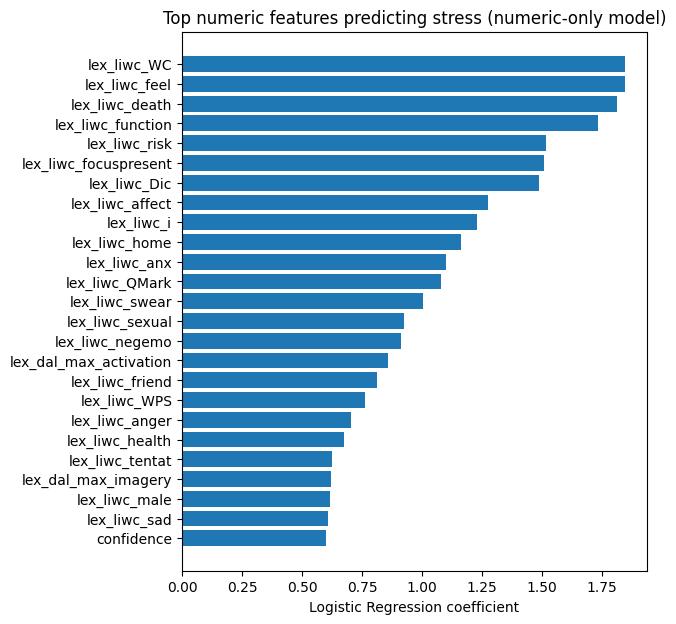

In [75]:
plt.figure(figsize=(6,7))
plt.barh(top_num_stress_df["feature"][::-1], top_num_stress_df["coef"][::-1])
plt.title("Top numeric features predicting stress (numeric-only model)")
plt.xlabel("Logistic Regression coefficient")
plt.show()

## Analysis 4: Cases where BERT and TF-IDF + Logistic Regression disagree

To analyze cases where BERT and TF-IDF + Logistic Regression disagree, we can look at the posts where one model predicts stressed while the other predicts non-stressed. By examining the text of these posts, we can try to understand why the models made different predictions.

In [76]:
comp_df = test_df.copy()
comp_df["y_true"] = y_test.values

comp_df["tfidf_pred"] = text_test_pred
comp_df["tfidf_p_stress"] = text_model.predict_proba(test_df[TEXT_COL])[:, 1]

comp_df["bert_pred"] = bert_test_pred
comp_df["bert_p_stress"] = torch.softmax(torch.tensor(bert_test_out.predictions), dim=1).numpy()[:, 1]

disagree_df = comp_df[comp_df["tfidf_pred"] != comp_df["bert_pred"]].copy()

disagree_df["tfidf_correct"] = (disagree_df["tfidf_pred"] == disagree_df["y_true"])
disagree_df["bert_correct"] = (disagree_df["bert_pred"] == disagree_df["y_true"])

print("Total disagreements:", len(disagree_df))
disagree_df[["id", "subreddit","y_true","tfidf_pred","bert_pred","tfidf_correct","bert_correct"]].head()

Total disagreements: 173


,id,subreddit,y_true,tfidf_pred,bert_pred,tfidf_correct,bert_correct
11,588,ptsd,1,0,1,False,True
21,6587,anxiety,0,1,0,False,True
22,108,anxiety,0,1,0,False,True
31,32340,domesticviolence,0,1,0,False,True
33,61,relationships,1,0,1,False,True


Row 1 (non-stressed): TF-IDF+LR predicts non-stressed likely because the keywords are more diluted. BERT predicts stressed likely because of strong distress cues like "hurt and depressed".

Row 2 (stressed): TF-IDF+LR predicts stressed likely because of keywords like "anxiety", "disorder", and "therapy". BERT predicts non-stressed likely because the overall context is more reflective and explanatory.

Row 3 (stressed): TF-IDF+LR predicts stressed likely because of keywords like "don't know", and "alone". BERT predicts non-stressed likely because of overall framing that is more observational but not distressed.

In [77]:
sample_df = disagree_df.sample(n=min(3, len(disagree_df)), random_state=RANDOM_STATE)

sample_cols = ["id","subreddit","y_true","tfidf_pred","bert_pred","tfidf_p_stress","bert_p_stress","tfidf_correct","bert_correct","text"]
sample_cols = [c for c in sample_cols if c in sample_df.columns]

pd.set_option("display.max_colwidth", None)
sample_df[sample_cols]

,id,subreddit,y_true,tfidf_pred,bert_pred,tfidf_p_stress,bert_p_stress,tfidf_correct,bert_correct,text
684,1007,relationships,0,0,1,0.448945,0.991961,True,False,He told me to never talk to him again and that he found someone else. I was so hurt and depressed. I've tried to talk to him and ask him what I've done to make him feel this way and he just continued to curse me and belittle me. He then ignored me and posted pictures of him and a girl all over his Instagram which he knew that I would see. I wanted to make him jealous too so I posted pictures of me and my friend on Instagram with heart emojis.
178,233,anxiety,0,1,0,0.656278,0.097830,False,True,"Hey guys, how are you? So, I've been diagnosed with anxiety disorder for 6 years now, though I know I've had it for more than ten years, I just didn't know it was an anxiety issue. I'm a 30 years old straight dude who started struggling with anxiety when I started to think I was gay (now I know this thing is called HOCD, but at the time I even came out as bisexual to my mother). After I went to therapy hoping to accept my sexuality, I discovered my problem wasn't self acceptance but an anxiety disorder, so that made sense, because I came out as bisexual even though I don't feel attracted to men. I thought I was burying my desires or something like that."
368,890,domesticviolence,0,1,0,0.641035,0.021568,False,True,"Hi! I live in an apartment block. There are 6 door entrances within a 5 meter proximity, so we can hear our neighbours slightly if they're very loud. I live next to an asian women I've never seen before. I don't know if she lives alone."


## Concluding Remarks

Beyond overall F1, the analyses highlight that stress detection is domain-dependent. Per-subreddit F1 shows that communities such as "anxiety", "ptsd", and "domesticviolence" are easier to predict and have larger sample sizes, likely because stress is expressed more explicitly. In contrast, "relationships" remains harder, which matches the intuition that relationship posts often contain mixed emotions, storytelling, and ambiguous distress cues.

The high-confidence error analysis suggests two recurring failure modes. False positives often occur when emotionally intense or trauma-related language appears in posts labeled as non-stressed (e.g., reflective narratives, third-person descriptions, or value/identity discussions). False negatives occur when stress is expressed indirectly through calm or solution-seeking language framing (e.g., parenting/financial strain) without strong negative emotion markers. This implies that "stress" in practice is not just negative wording, but also context and intent.

Interpretability analyses support this: the TF-IDF model's top phrases are dominated by emotionally loaded words and uncertainty markers (e.g., fear/anxiety terms), while the numeric model emphasizes LIWC affect/self-focus/verbosity signals (e.g., negemo, anx, first-person language, word count). Comparing TF-IDF and BERT disagreement cases shows that TF-IDF is more sensitive to surface keywords, whereas BERT is more sensitive to broader narrative context, sometimes helping in subtle cases, but also occasionally overreacting to emotionally intense stories that annotators labeled as non-stressed.

A model like BERT could support monitoring in real-world mental health discourse platforms (e.g., summarizing trends or surfacing posts that may benefit from support), but it should not be treated as a diagnostic tool. The main risks are false negatives like missing individuals who need help and false positives like unnecessary flagging of non-stressed posts, which can feel intrusive. Domain shift is also a major concern: performance may drop when applied outside Reddit or to communities with different language norms. Finally, subreddit-level prevalence differences raise the risk of shortcut learning and community stereotyping if deployment is not carefully designed.

To deploy responsibly, this system should have a human in the loop, and users need to consent to being diagnosed by a model, and framed as a decision-support tool. Practical mitigations include conservative thresholding, prioritising recall in safety-critical settings, monitoring subgroup performance (by community/topic), and providing interpretable evidence (e.g., key phrases/features) to support review rather than automated action.